# Missing Indicator Imputer

---

## 1. Tổng quan & Khái niệm
**Missing Indicator Imputer** là một kỹ thuật xử lý dữ liệu thiếu (*missing values*) nâng cao trong Học máy (Machine Learning) và Phân tích dữ liệu. 

Thay vì chỉ lấp đầy các ô trống một cách đơn thuần, kỹ thuật này **tạo ra một biến nhị phân mới (0 hoặc 1)** — gọi là các *missing indicators* — để đánh dấu chính xác vị trí của các giá trị thiếu trong cột dữ liệu gốc.

> **Phạm vi áp dụng:** Thường được áp dụng hiệu quả nhất cho dữ liệu thiếu thuộc loại **MNAR** (Missing Not at Random) hoặc **MAR** (Missing At Random).

---

## 2. Cơ chế Hoạt động
Quy trình xử lý của phương pháp này bao gồm 2 bước phối hợp:

1. **Đánh dấu (Indicator):** Nếu ô dữ liệu trong cột gốc bị khuyết, giá trị ô tương ứng trong biến nhị phân thêm vào sẽ là `1` (hoặc `True`), ngược lại sẽ bằng `0` (hoặc `False`) nếu ô đó chứa dữ liệu đầy đủ.
2. **Điền khuyết (Imputation):** Đồng thời, các ô dữ liệu khuyết tại cột gốc sẽ được điền bằng một giá trị đại diện như giá trị trung bình (*mean*), trung vị (*median*), hoặc số `0` (thông thường thông qua phương pháp `SimpleImputer`).

Cuối cùng, thuật toán kết hợp các biến gốc đã được điền khuyết và các biến nhị phân mới tạo thành một bộ dữ liệu cải tiến để đưa vào mô hình huấn luyện.

---

## 3. Ý nghĩa & Tầm quan trọng

Đối với dữ liệu thiếu loại **MNAR** và **MAR**, nếu chỉ sử dụng các phương pháp điền khuyết thông thường, chúng ta sẽ làm mất đi thông tin quan trọng về hành vi khuyết thiếu (*informative missingness*). Sự khuyết thiếu này thường mang một mô hình (pattern) ẩn có liên quan mật thiết với mục tiêu dự đoán.

> **Ví dụ thực tế:** Trong bài toán dự đoán khả năng nợ xấu ngân hàng dựa trên cột *"Số năm kinh nghiệm làm việc"*:
> * Những người đang thất nghiệp thường có xu hướng bỏ trống ô này.
> * Nếu ta điền giá trị trung bình (ví dụ: `5 năm`) vào các ô trống đó, mô hình sẽ hiểu lầm một người thất nghiệp (nguy cơ rủi ro cao) thành một người có kinh nghiệm trung bình (nguy cơ rủi ro vừa phải).
> * **Giải pháp:** Việc dùng thêm biến nhị phân chỉ báo sẽ giúp mô hình "hiểu" được: *“À, người này có giá trị điền khuyết là 5, nhưng họ thuộc nhóm từng để trống (thất nghiệp)”*, từ đó tối ưu hóa hiệu suất dự báo.

---

## 4. Lợi ích & Hạn chế

### Lợi ích và Ứng dụng
* **Hiệu quả cao với MNAR:** Rất mạnh mẽ khi sự thiếu hụt dữ liệu không ngẫu nhiên (ví dụ: người thu nhập cực cao từ chối khai báo tài sản).
* **Cải thiện thuật toán:** Tăng rõ rệt hiệu suất của các mô hình tuyến tính (*Linear Regression*, *Logistic Regression*) và các mô hình dựa trên cây (*Tree-based models* như *Decision Tree*, *Random Forest*).
* **Phù hợp dữ liệu lớn:** Giảm thiểu tối đa độ lệch (*bias*) hệ thống so với việc chỉ điền khuyết đơn thuần.

### Hạn chế
* **Không dùng cho MCAR:** Nếu dữ liệu thiếu hoàn toàn ngẫu nhiên (Missing Completely at Random), việc tạo thêm cột chỉ báo chỉ làm tăng kích thước dữ liệu và tạo ra nhiễu (*noise*) không cần thiết.
* **Dữ liệu đa chiều (High-dimensional):** Trong các tập dữ liệu có quá nhiều cột, kỹ thuật này có thể làm bùng nổ số lượng tính năng. Khi đó, phương pháp *Selective MIM (Missing Indicator Method)* nên được cân nhắc để đảm bảo tính ổn định.

---

## 5. Chi tiết trong thư viện Scikit-Learn

Cấu trúc khởi tạo từ thư viện:
```python
class sklearn.impute.MissingIndicator(*, missing_values=nan, features='missing-only', sparse='auto', error_on_new=True)
```
### 5.1. Chi tiết các tham số (Parameters)

* **`missing_values`** *(Mặc định: `np.nan`)*: 
  Giá trị được coi là dữ liệu khuyết. Hàm sẽ tìm và đánh dấu các giá trị này (có thể là số, chuỗi, hoặc `None`).
* **`features`** *(Mặc định: `'missing-only'`)*: 
  Chọn loại cột để tạo nhãn đánh dấu.
  * `'missing-only'`: Chỉ tạo cột đánh dấu cho những biến thực sự có dữ liệu khuyết khi huấn luyện (`fit`).
  * `'all'`: Tạo cột đánh dấu cho tất cả các biến, bất kể cột đó có thiếu dữ liệu hay không.
* **`sparse`** *(Mặc định: `'auto'`)*: 
  Định dạng của ma trận kết quả.
  * `'auto'`: Tự động chọn định dạng giống như dữ liệu đầu vào.
  * `True`: Trả về ma trận thưa (*sparse matrix*) để tiết kiệm bộ nhớ.
  * `False`: Trả về mảng numpy thông thường (*dense array*).
* **`error_on_new`** *(Mặc định: `True`)*: 
  Chỉ áp dụng khi `features='missing-only'`. Nếu đặt là `True`, hàm sẽ báo lỗi nếu khi dự đoán (`transform`) xuất hiện dữ liệu khuyết ở một cột vốn hoàn toàn đầy đủ lúc huấn luyện (`fit`).

---

### 5.2. Các nhóm phương thức chi tiết (Methods)

#### 1. Nhóm phương thức chính (Xử lý dữ liệu)
* **`fit(X, y=None)`**: Dùng để "học" cấu trúc của dữ liệu $X$ (xác định xem những cột nào đang bị thiếu dữ liệu).
  * **Tham số:** 
    * `X`: Dữ liệu đầu vào (mảng hoặc ma trận).
    * `y`: Bị bỏ qua (chỉ thêm vào cho đúng chuẩn chung của thư viện).
  * **Kết quả:** Trả về chính mô hình đã được huấn luyện.
* **`transform(X)`**: Dùng sau khi đã `fit`, chuyển đổi dữ liệu $X$ thành một ma trận Boolean (`True`/`False`) đánh dấu vị trí các giá trị bị khuyết.
  * **Tham số:** `X` là dữ liệu cần kiểm tra vị trí khuyết.
  * **Kết quả:** Trả về ma trận $X_t$ chứa các giá trị `True` (bị khuyết) và `False` (không bị khuyết).
* **`fit_transform(X, y=None)`**: Gom cả 2 bước `fit` và `transform` vào làm một để chạy nhanh hơn và viết code gọn hơn.
  * **Tham số:** Tương tự như hàm `fit`.
  * **Kết quả:** Trả về ngay ma trận Boolean đánh dấu dữ liệu khuyết.

#### 2. Nhóm phương thức quản lý tên cột và định dạng đầu ra
* **`get_feature_names_out(input_features=None)`**: Lấy danh sách tên của các cột đầu ra sau khi biến đổi.
  * **Tham số:** `input_features` *(Mặc định: `None`)* là danh sách tên cột đầu vào. Nếu bạn không truyền vào, hàm sẽ tự lấy tên cũ hoặc tự tạo tên theo dạng `x0`, `x1`, `x2`,...
  * **Kết quả:** Mảng chứa tên của các cột đầu ra.
* **`set_output(*, transform=None)`**: Thiết lập định dạng dữ liệu trả về sau khi gọi hàm `transform` hoặc `fit_transform`.
  * **Tham số:** `transform` nhận một trong các giá trị:
    * `"default"`: Trả về dạng mặc định của scikit-learn (mảng Numpy hoặc ma trận thưa).
    * `"pandas"`: Trả về dạng DataFrame của **Pandas**.
    * `"polars"`: Trả về dạng DataFrame của **Polars**.
    * `None`: Giữ nguyên cấu hình cũ.

#### 3. Nhóm phương thức cấu hình hệ thống (Ít dùng trực tiếp)
* **`get_params(deep=True)`**: Lấy ra danh sách các tham số hiện tại của mô hình và giá trị của chúng (Trả về một từ điển `dict`). Tham số `deep=True` giúp lấy luôn tham số của các bộ lọc con bên trong (nếu có).
* **`set_params(**params)`**: Cài đặt hoặc thay đổi giá trị cho các tham số của mô hình mà không cần khởi tạo lại từ đầu.
* **`get_metadata_routing()`**: Lấy thông tin cấu hình định tuyến dữ liệu trung gian (*metadata*) của mô hình (thường dùng trong các hệ thống `Pipeline` phức tạp).

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import MissingIndicator, SimpleImputer
import missingno as msno
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, f1_score, accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.impute import IterativeImputer, SimpleImputer, KNNImputer
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               ExtraTreesRegressor)
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')
from imputer_tools_mi import missing_imputer, calculate_nrmse

np.random.seed(42)

* MCAR

Kích thước dữ liệu: (1000, 3)
Thống kê dữ liệu:



,Age,Education,Income
count,1000.000000,1000.000000,740.000000
mean,44.830000,14.444000,5035.620741
std,14.346809,2.886034,1577.887959
min,20.000000,10.000000,-82.642124
25%,33.000000,12.000000,3923.645396
50%,45.000000,14.000000,5115.515722
75%,56.000000,17.000000,6122.208487
max,69.000000,19.000000,9881.970940


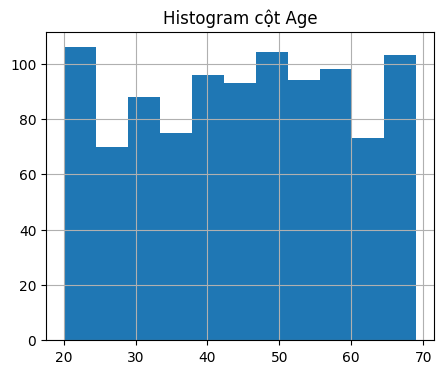

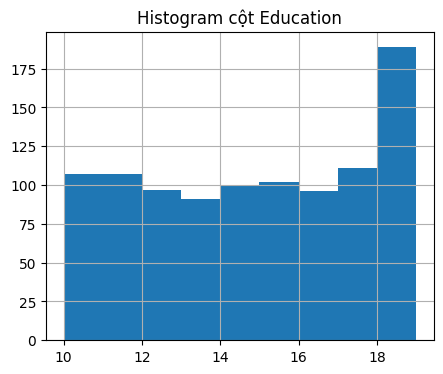

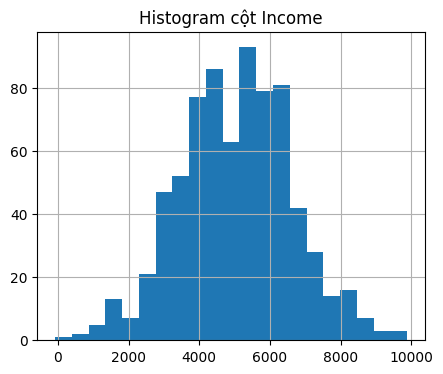

Các cột thiếu: ['Income']


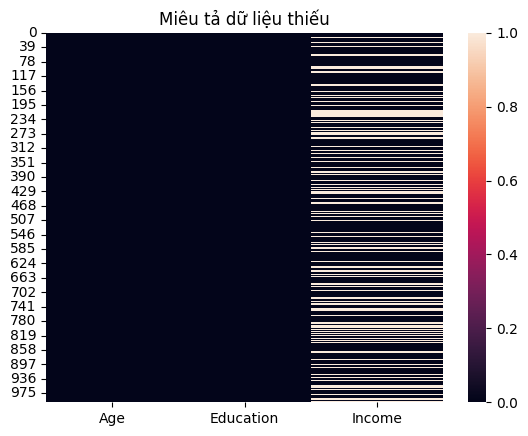

Bảng so sánh sơ bộ (MAE tăng dần)


,Configuration,MSE,MAE
1,SimpleImputer,486721.832590,273.381582
2,SimpleImputer + Indicator,486721.832590,273.381582
0,IterativeImputer\nBayesianRidge(max_iter=20),486706.766453,273.389069
3,KNNImputer,930664.108040,404.174521


In [2]:
mcar = pd.read_csv('../data/synthetic data/MCAR/dataset_missing.csv')
org_mcar = pd.read_csv('../data/synthetic data/MCAR/dataset_goc.csv')
print(f"Kích thước dữ liệu: {mcar.shape}")
print("Thống kê dữ liệu:\n")
display(mcar.describe())

# Phân phối dữ liệu
for col in mcar.columns:
    plt.figure(figsize=(5,4))
    mcar[col].hist(bins='auto')
    plt.title(f'Histogram cột {col}')
    plt.show()

# Lấy cột có missing values
missing_cols = mcar.columns[mcar.isna().any()].tolist()
print(f"Các cột thiếu: {missing_cols}")

# Heatmap giá trị thiếu
plt.figure()
sns.heatmap(mcar.isnull())
plt.title('Miêu tả dữ liệu thiếu')
plt.show()

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
clf = RandomForestClassifier(n_estimators=200, random_state=7, max_depth=10, min_samples_leaf=4)
# Khi đặt max_depth=10, min_samples_leaf=4 giúp giảm hiện tượng "học vẹt" giúp mô hình học tốt hơn
# tăng độ chính xác cho MI imputer

# Split train-test
train_idx, test_idx = train_test_split(range(len(mcar)),test_size=0.2, shuffle=True, random_state=42)

# Reset index NGOÀI vòng lặp, lưu bản gốc
X_train_raw = mcar.iloc[train_idx].reset_index(drop=True)
X_test_raw  = mcar.iloc[test_idx].reset_index(drop=True)
X_test_org  = org_mcar.iloc[test_idx].reset_index(drop=True)

configs = {
    # IterativeImputer – 4 configurations
    'IterativeImputer\nBayesianRidge(max_iter=20)':  {'imputer': IterativeImputer(estimator=BayesianRidge(),
                                           max_iter=20, random_state=0), 'use_indicator': False},
    'SimpleImputer': {'imputer': SimpleImputer(strategy='mean'), 'use_indicator': False},
    'SimpleImputer + Indicator': {'imputer': SimpleImputer(strategy='mean'), 'use_indicator': True},
    'KNNImputer': {'imputer': KNNImputer(n_neighbors=5, weights='distance'), 'use_indicator': False}
}

results = []

for config_name, params in configs.items():
    imp = params['imputer']
    use_indicator = params['use_indicator']
    
    # 1. Copy dữ liệu
    X_train = X_train_raw.copy()
    X_test  = X_test_raw.copy()
    missing_mask_train = X_train.isna()
    missing_mask_test  = X_test.isna()

    # 2. Xử lý Missing Indicator (Nếu có)
    # Chúng ta phải tạo Indicator trước khi Scale/Impute
    if use_indicator:
        mi = MissingIndicator(features='missing-only')
        mi.fit(X_train)
        # Lấy tên cột mới
        indicator_cols = [f"{c}_miss" for c in mi.get_feature_names_out()]
        
        # Tạo dataframe indicator
        X_train_ind = pd.DataFrame(mi.transform(X_train).astype(int), columns=indicator_cols, index=X_train.index)
        X_test_ind  = pd.DataFrame(mi.transform(X_test).astype(int), columns=indicator_cols, index=X_test.index)
    
    # 3. Scale dữ liệu (Chỉ scale trên các cột gốc)
    train_mean = X_train.mean()
    X_train_filled = X_train.fillna(train_mean)
    X_test_filled  = X_test.fillna(train_mean)
    
    scaler = StandardScaler()
    scaler.fit(X_train_filled)
    X_train_scaled = pd.DataFrame(scaler.transform(X_train_filled), columns=X_train.columns)
    X_test_scaled  = pd.DataFrame(scaler.transform(X_test_filled), columns=X_test.columns)
    
    # Gán lại NaN
    X_train_scaled[missing_mask_train] = np.nan
    X_test_scaled[missing_mask_test]   = np.nan
    
    # 4. Impute
    imp.fit(X_train_scaled)
    data_out = pd.DataFrame(imp.transform(X_test_scaled), columns=X_test_scaled.columns)
    
    # 5. Inverse transform (Chỉ trên các cột gốc)
    data_original_scale = pd.DataFrame(
        scaler.inverse_transform(data_out), columns=X_test_scaled.columns
    )
    
    # 6. Nếu có Indicator, ghép vào sau để đánh giá (hoặc huấn luyện model sau này)
    if use_indicator:
        data_original_scale = pd.concat([data_original_scale, X_test_ind.reset_index(drop=True)], axis=1)

    # 7. Tính MSE/MAE (Chỉ trên các cột gốc ban đầu)
    # Lưu ý: Chúng ta chỉ tính lỗi trên các cột có missing (dữ liệu số)
    mse = mean_squared_error(X_test_org[missing_cols], data_original_scale[missing_cols])
    mae = mean_absolute_error(X_test_org[missing_cols], data_original_scale[missing_cols])

    results.append({
        'Configuration': config_name,
        'MSE': mse,
        'MAE': mae,
    })

results = pd.DataFrame(results)
print('Bảng so sánh sơ bộ (MAE tăng dần)')
display(results.sort_values('MAE'))

# Visualization

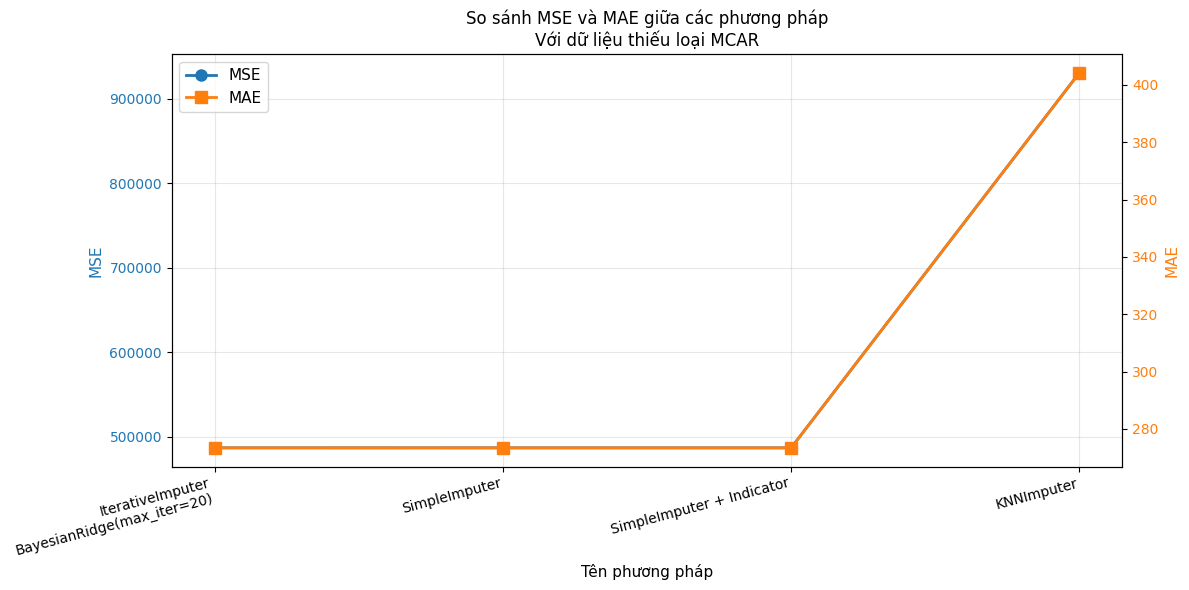

In [3]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x = results['Configuration']
y_mse = results['MSE']
y_mae = results['MAE']
x_pos = range(len(x))

# Trục Y trái cho MSE
ax1.plot(x_pos, y_mse, label="MSE", marker='o', linewidth=2, markersize=8, color='#1f77b4')
ax1.set_xlabel("Tên phương pháp", fontsize=11)
ax1.set_ylabel("MSE", fontsize=11, color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.grid(True, alpha=0.3)

# Trục Y phải cho MAE
ax2 = ax1.twinx()
ax2.plot(x_pos, y_mae, label="MAE", marker='s', linewidth=2, markersize=8, color='#ff7f0e')
ax2.set_ylabel("MAE", fontsize=11, color='#ff7f0e')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

plt.title("So sánh MSE và MAE giữa các phương pháp\nVới dữ liệu thiếu loại MCAR", fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x, rotation=15, ha='right', fontsize=10)

# Hợp nhất legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11)

plt.tight_layout()
plt.show()

* MNAR

Kích thước dữ liệu: (1000, 3)
Thống kê dữ liệu:



,Age,Education,Income
count,1000.000000,1000.000000,83.000000
mean,44.830000,14.444000,3451.870289
std,14.346809,2.886034,1515.510276
min,20.000000,10.000000,-82.642124
25%,33.000000,12.000000,2336.569279
50%,45.000000,14.000000,3310.179782
75%,56.000000,17.000000,4546.312890
max,69.000000,19.000000,6285.637995


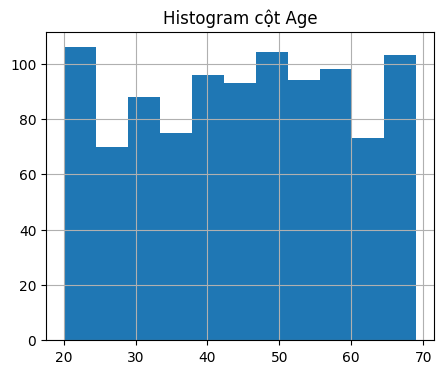

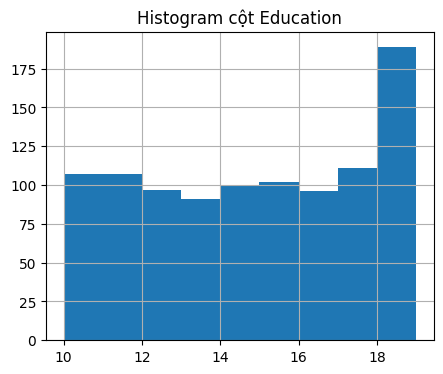

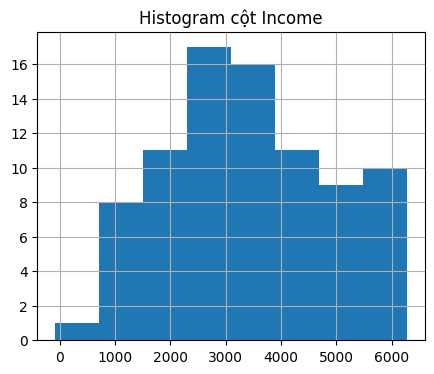

Các cột thiếu: ['Income']


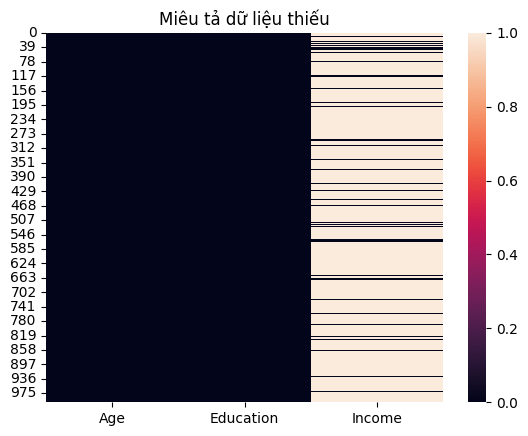

Kết quả:



,Configuration,MSE,MAE
1,SimpleImputer,4.206453e+06,1633.532671
2,SimpleImputer + Indicator,4.206453e+06,1633.532671
0,IterativeImputer\nBayesianRidge(max_iter=20),4.240884e+06,1641.318735
3,KNNImputer,5.089896e+06,1755.631396


In [4]:
mnar = pd.read_csv('../data/synthetic data/MNAR/dataset_missing.csv')
org_mnar = pd.read_csv('../data/synthetic data/MNAR/dataset_goc.csv')
print(f"Kích thước dữ liệu: {mnar.shape}")
print("Thống kê dữ liệu:\n")
display(mnar.describe())

# Phân phối dữ liệu
for col in mnar.columns:
    plt.figure(figsize=(5,4))
    mnar[col].hist(bins='auto')
    plt.title(f'Histogram cột {col}')
    plt.show()

# Lấy cột có missing values
missing_cols = mnar.columns[mnar.isna().any()].tolist()
print(f"Các cột thiếu: {missing_cols}")

# Heatmap giá trị thiếu
plt.figure()
sns.heatmap(mnar.isnull())
plt.title('Miêu tả dữ liệu thiếu')
plt.show()

# Split train-test
train_idx, test_idx = train_test_split(range(len(mnar)),test_size=0.2, shuffle=True, random_state=42)

# Reset index NGOÀI vòng lặp, lưu bản gốc
X_train_raw = mnar.iloc[train_idx].reset_index(drop=True)
X_test_raw  = mnar.iloc[test_idx].reset_index(drop=True)
X_test_org  = org_mnar.iloc[test_idx].reset_index(drop=True)

mnar_results = []
for config_name, params in configs.items():
    imp = params['imputer']
    use_indicator = params['use_indicator']
    
    # 1. Copy dữ liệu
    X_train = X_train_raw.copy()
    X_test  = X_test_raw.copy()
    missing_mask_train = X_train.isna()
    missing_mask_test  = X_test.isna()

    # 2. Xử lý Missing Indicator (Nếu có)
    # Chúng ta phải tạo Indicator trước khi Scale/Impute
    if use_indicator:
        mi = MissingIndicator(features='missing-only')
        mi.fit(X_train)
        # Lấy tên cột mới
        indicator_cols = [f"{c}_miss" for c in mi.get_feature_names_out()]
        
        # Tạo dataframe indicator
        X_train_ind = pd.DataFrame(mi.transform(X_train).astype(int), columns=indicator_cols, index=X_train.index)
        X_test_ind  = pd.DataFrame(mi.transform(X_test).astype(int), columns=indicator_cols, index=X_test.index)
    
    # 3. Scale dữ liệu (Chỉ scale trên các cột gốc)
    train_mean = X_train.mean()
    X_train_filled = X_train.fillna(train_mean)
    X_test_filled  = X_test.fillna(train_mean)
    
    scaler = StandardScaler()
    scaler.fit(X_train_filled)
    X_train_scaled = pd.DataFrame(scaler.transform(X_train_filled), columns=X_train.columns)
    X_test_scaled  = pd.DataFrame(scaler.transform(X_test_filled), columns=X_test.columns)
    
    # Gán lại NaN
    X_train_scaled[missing_mask_train] = np.nan
    X_test_scaled[missing_mask_test]   = np.nan
    
    # 4. Impute
    imp.fit(X_train_scaled)
    data_out = pd.DataFrame(imp.transform(X_test_scaled), columns=X_test_scaled.columns)
    
    # 5. Inverse transform (Chỉ trên các cột gốc)
    data_original_scale = pd.DataFrame(
        scaler.inverse_transform(data_out), columns=X_test_scaled.columns
    )
    
    # 6. Nếu có Indicator, ghép vào sau để đánh giá (hoặc huấn luyện model sau này)
    if use_indicator:
        data_original_scale = pd.concat([data_original_scale, X_test_ind.reset_index(drop=True)], axis=1)

    # 7. Tính MSE/MAE (Chỉ trên các cột gốc ban đầu)
    # Lưu ý: Chúng ta chỉ tính lỗi trên các cột có missing (dữ liệu số)
    mse = mean_squared_error(X_test_org[missing_cols], data_original_scale[missing_cols])
    mae = mean_absolute_error(X_test_org[missing_cols], data_original_scale[missing_cols])

    mnar_results.append({
        'Configuration': config_name,
        'MSE': mse,
        'MAE': mae,
    })

print("Kết quả:\n")
mnar_results = pd.DataFrame(mnar_results)
display(mnar_results.sort_values(['MSE', 'MAE']))

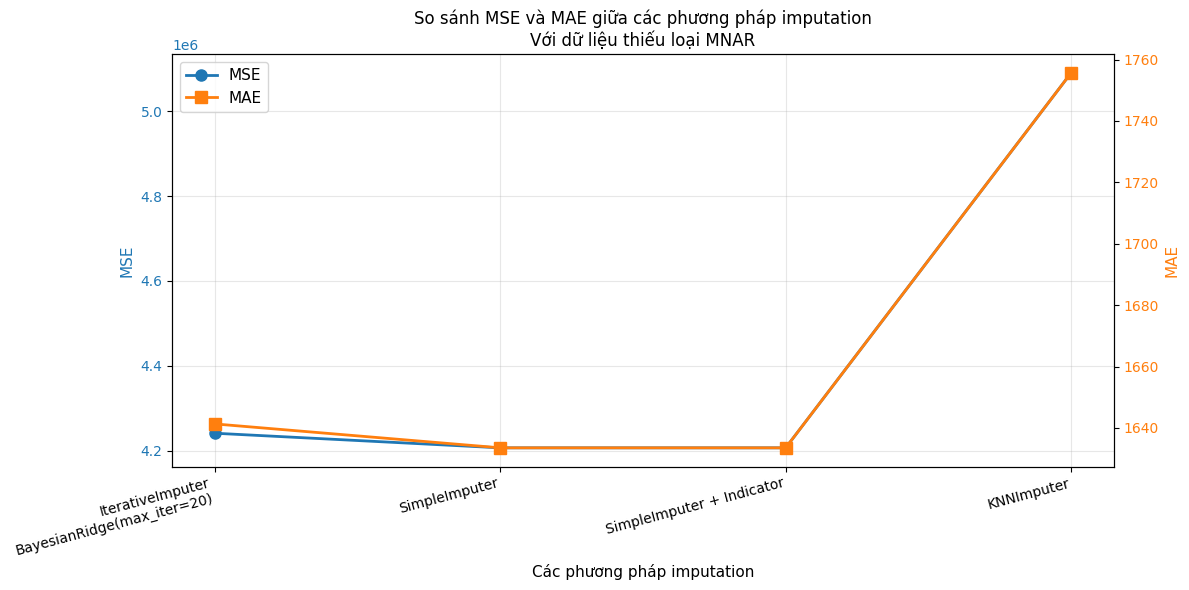

In [5]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x = mnar_results['Configuration']
y_mse = mnar_results['MSE']
y_mae = mnar_results['MAE']
x_pos = range(len(x))

# Trục Y trái cho MSE
ax1.plot(x_pos, y_mse, label="MSE", marker='o', linewidth=2, markersize=8, color='#1f77b4')
ax1.set_xlabel("Các phương pháp imputation", fontsize=11)
ax1.set_ylabel("MSE", fontsize=11, color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.grid(True, alpha=0.3)

# Trục Y phải cho MAE
ax2 = ax1.twinx()
ax2.plot(x_pos, y_mae, label="MAE", marker='s', linewidth=2, markersize=8, color='#ff7f0e')
ax2.set_ylabel("MAE", fontsize=11, color='#ff7f0e')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

plt.title("So sánh MSE và MAE giữa các phương pháp imputation\nVới dữ liệu thiếu loại MNAR", fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x, rotation=15, ha='right', fontsize=10)

# Hợp nhất legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11)

plt.tight_layout()
plt.show()

* Dataset kết hợp

,Age,Education,Income,Experience
0,58.0,18.0,6214.957431,10.0
1,48.0,NaN,4380.284251,14.0
2,34.0,14.0,4786.980575,31.0
3,62.0,NaN,5580.463217,27.0
4,27.0,14.0,4358.274699,21.0


Kích thước dữ liệu: (1000, 4)
Thống kê dữ liệu:



,Age,Education,Income,Experience
count,840.000000,668.000000,713.000000,898.000000
mean,44.508333,14.519461,5122.014489,19.465479
std,14.322688,2.897744,867.874885,11.514492
min,20.000000,10.000000,2855.142225,0.000000
25%,32.750000,12.000000,4488.420183,10.000000
50%,45.000000,15.000000,5178.049607,19.500000
75%,56.000000,17.000000,5727.712890,29.000000
max,69.000000,19.000000,7517.481470,39.000000


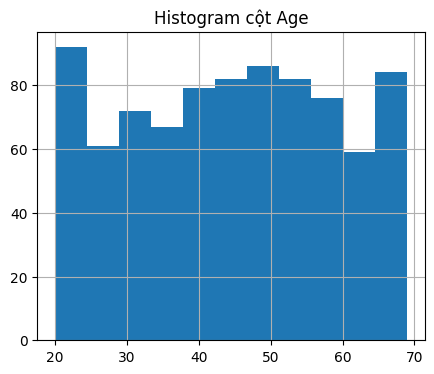

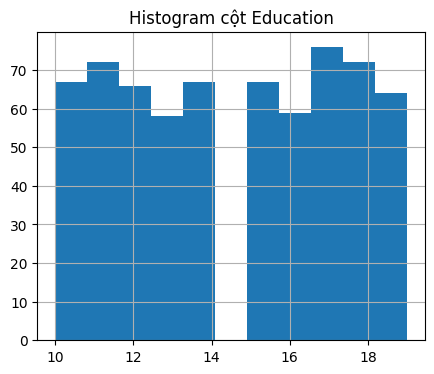

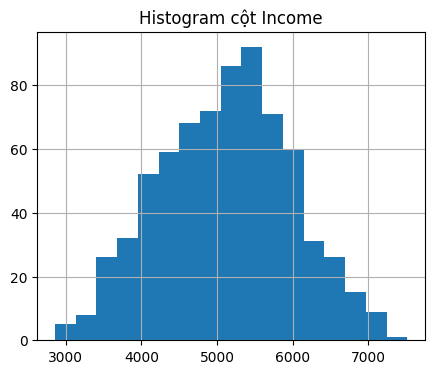

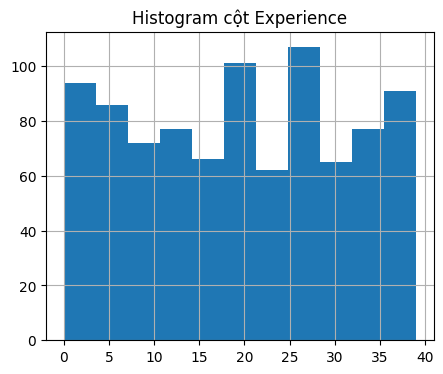

Các cột thiếu: ['Age', 'Education', 'Income', 'Experience']


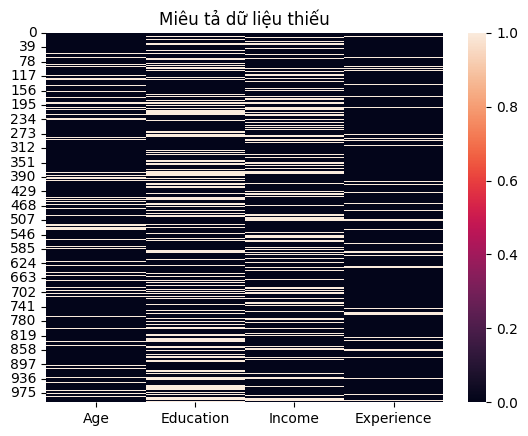

Kết quả:



,Configuration,MSE,MAE
0,IterativeImputer\nBayesianRidge(max_iter=20),25333.685043,31.727583
3,KNNImputer,61150.698151,52.072536
1,SimpleImputer,62798.819683,51.947744
2,SimpleImputer + Indicator,62798.819683,51.947744


In [6]:
combined = pd.read_csv('../data/synthetic data/ket_hop/dataset_missing.csv')
org_combined = pd.read_csv('../data/synthetic data/ket_hop/dataset_goc.csv')
display(combined.head())
print(f"Kích thước dữ liệu: {combined.shape}")
print("Thống kê dữ liệu:\n")
display(combined.describe())

# Phân phối dữ liệu
for col in combined.columns:
    plt.figure(figsize=(5,4))
    combined[col].hist(bins='auto')
    plt.title(f'Histogram cột {col}')
    plt.show()

# Lấy cột có missing values
missing_cols = combined.columns[combined.isna().any()].tolist()
print(f"Các cột thiếu: {missing_cols}")

# Heatmap giá trị thiếu
plt.figure()
sns.heatmap(combined.isnull())
plt.title('Miêu tả dữ liệu thiếu')
plt.show()

# Split train-test
train_idx, test_idx = train_test_split(range(len(combined)),test_size=0.2, shuffle=True, random_state=42)

# Reset index NGOÀI vòng lặp, lưu bản gốc
X_train_raw = combined.iloc[train_idx].reset_index(drop=True)
X_test_raw  = combined.iloc[test_idx].reset_index(drop=True)
X_test_org  = org_combined.iloc[test_idx].reset_index(drop=True)

combined_results = []
for config_name, params in configs.items():
    imp = params['imputer']
    use_indicator = params['use_indicator']
    
    # 1. Copy dữ liệu
    X_train = X_train_raw.copy()
    X_test  = X_test_raw.copy()
    missing_mask_train = X_train.isna()
    missing_mask_test  = X_test.isna()

    # 2. Xử lý Missing Indicator (Nếu có)
    # Chúng ta phải tạo Indicator trước khi Scale/Impute
    if use_indicator:
        mi = MissingIndicator(features='missing-only')
        mi.fit(X_train)
        # Lấy tên cột mới
        indicator_cols = [f"{c}_miss" for c in mi.get_feature_names_out()]
        
        # Tạo dataframe indicator
        X_train_ind = pd.DataFrame(mi.transform(X_train).astype(int), columns=indicator_cols, index=X_train.index)
        X_test_ind  = pd.DataFrame(mi.transform(X_test).astype(int), columns=indicator_cols, index=X_test.index)
    
    # 3. Scale dữ liệu (Chỉ scale trên các cột gốc)
    train_mean = X_train.mean()
    X_train_filled = X_train.fillna(train_mean)
    X_test_filled  = X_test.fillna(train_mean)
    
    scaler = StandardScaler()
    scaler.fit(X_train_filled)
    X_train_scaled = pd.DataFrame(scaler.transform(X_train_filled), columns=X_train.columns)
    X_test_scaled  = pd.DataFrame(scaler.transform(X_test_filled), columns=X_test.columns)
    
    # Gán lại NaN
    X_train_scaled[missing_mask_train] = np.nan
    X_test_scaled[missing_mask_test]   = np.nan
    
    # 4. Impute
    imp.fit(X_train_scaled)
    data_out = pd.DataFrame(imp.transform(X_test_scaled), columns=X_test_scaled.columns)
    
    # 5. Inverse transform (Chỉ trên các cột gốc)
    data_original_scale = pd.DataFrame(
        scaler.inverse_transform(data_out), columns=X_test_scaled.columns
    )
    
    # 6. Nếu có Indicator, ghép vào sau để đánh giá (hoặc huấn luyện model sau này)
    if use_indicator:
        data_original_scale = pd.concat([data_original_scale, X_test_ind.reset_index(drop=True)], axis=1)

    # 7. Tính MSE/MAE (Chỉ trên các cột gốc ban đầu)
    # Lưu ý: Chúng ta chỉ tính lỗi trên các cột có missing (dữ liệu số)
    mse = mean_squared_error(X_test_org[missing_cols], data_original_scale[missing_cols])
    mae = mean_absolute_error(X_test_org[missing_cols], data_original_scale[missing_cols])

    combined_results.append({
        'Configuration': config_name,
        'MSE': mse,
        'MAE': mae,
    })

print("Kết quả:\n")
combined_results = pd.DataFrame(combined_results)
display(combined_results.sort_values(['MSE', 'MAE']))


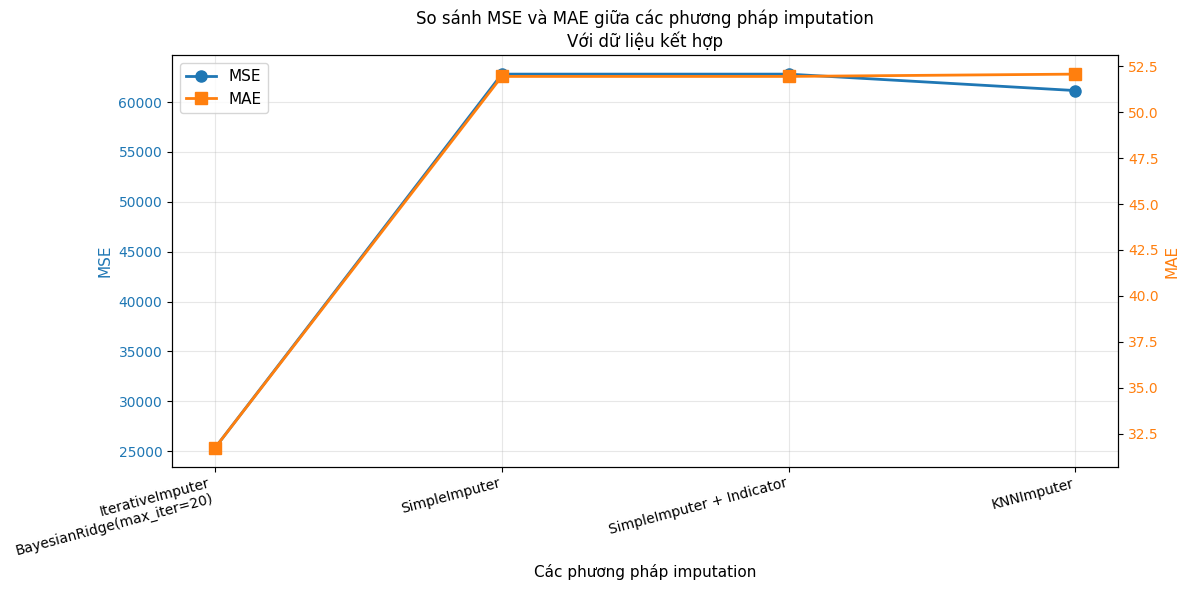

In [7]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x = combined_results['Configuration']
y_mse = combined_results['MSE']
y_mae = combined_results['MAE']
x_pos = range(len(x))

# Trục Y trái cho MSE
ax1.plot(x_pos, y_mse, label="MSE", marker='o', linewidth=2, markersize=8, color='#1f77b4')
ax1.set_xlabel("Các phương pháp imputation", fontsize=11)
ax1.set_ylabel("MSE", fontsize=11, color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.grid(True, alpha=0.3)

# Trục Y phải cho MAE
ax2 = ax1.twinx()
ax2.plot(x_pos, y_mae, label="MAE", marker='s', linewidth=2, markersize=8, color='#ff7f0e')
ax2.set_ylabel("MAE", fontsize=11, color='#ff7f0e')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

plt.title("So sánh MSE và MAE giữa các phương pháp imputation\nVới dữ liệu kết hợp", fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x, rotation=15, ha='right', fontsize=10)

# Hợp nhất legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11)

plt.tight_layout()
plt.show()

# Run in Realistic Datasets

* Horse Colic

In [8]:
hc_raw = pd.read_csv('../data/real data/horse_colic_train.csv')
display(hc_raw.head())

,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,no,adult,530101,38.5,66.0,28.0,cool,reduced,NaN,more_3_sec,...,45.0,8.4,NaN,NaN,died,no,11300,0,0,no
1,yes,adult,534817,39.2,88.0,20.0,NaN,NaN,pale_cyanotic,less_3_sec,...,50.0,85.0,cloudy,2.0,euthanized,no,2208,0,0,no
2,no,adult,530334,38.3,40.0,24.0,normal,normal,pale_pink,less_3_sec,...,33.0,6.7,NaN,NaN,lived,no,0,0,0,yes
3,yes,young,5290409,39.1,164.0,84.0,cold,normal,dark_cyanotic,more_3_sec,...,48.0,7.2,serosanguious,5.3,died,yes,2208,0,0,yes
4,no,adult,530255,37.3,104.0,35.0,NaN,NaN,dark_cyanotic,more_3_sec,...,74.0,7.4,NaN,NaN,died,no,4300,0,0,no


Kích thước: (299, 58)
Thống kê dữ liệu:



,Unnamed: 0,surgery,age,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,capillary_refill_time,pain,...,nasogastric_reflux_ph_missing,packed_cell_volume_missing,total_protein_missing,abdomo_protein_missing,pain_missing,abdomo_appearance_missing,lesion_site,lesion_type,lesion_subtype,lesion_specific_code
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,243.000000,230.000000,267.000000,299.000000,...,299.000000,299.00000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,149.000000,0.602007,0.919732,30.509365,66.220736,24.551839,1.456790,1.504348,0.292135,1.377926,...,0.822742,0.09699,0.110368,0.662207,0.183946,0.551839,3.505017,1.474916,0.424749,2.953177
std,86.458082,0.490305,0.272162,15.326224,33.741787,19.922496,0.848665,0.603829,0.455598,1.642856,...,0.382527,0.29644,0.313873,0.473750,0.388090,0.498139,5.397844,1.103019,0.652967,3.014141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,74.500000,0.000000,1.000000,37.200000,48.000000,12.000000,1.000000,1.000000,0.000000,0.000000,...,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000
50%,149.000000,1.000000,1.000000,38.000000,60.000000,22.000000,1.000000,2.000000,0.000000,1.000000,...,1.000000,0.00000,0.000000,1.000000,0.000000,1.000000,2.000000,1.000000,0.000000,2.000000
75%,223.500000,1.000000,1.000000,38.500000,88.000000,34.500000,2.000000,2.000000,1.000000,3.000000,...,1.000000,0.00000,0.000000,1.000000,0.000000,1.000000,3.000000,2.000000,1.000000,5.000000
max,298.000000,1.000000,1.000000,40.800000,184.000000,96.000000,3.000000,3.000000,1.000000,4.000000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,41.000000,4.000000,3.000000,9.000000


  rectal_temp: thay 60 giá trị 0 → NaN
  pulse: thay 24 giá trị 0 → NaN
  respiratory_rate: thay 58 giá trị 0 → NaN

Missing values sau tiền xử lý:
rectal_temp               60
pulse                     24
respiratory_rate          58
temp_of_extremities       56
peripheral_pulse          69
capillary_refill_time     32
abdominal_distention      56
nasogastric_tube         104
rectal_exam_feces        102
abdomen                  118
dtype: int64

Phân phối target 'surgical_lesion':
surgical_lesion
1    190
0    109
Name: count, dtype: int64


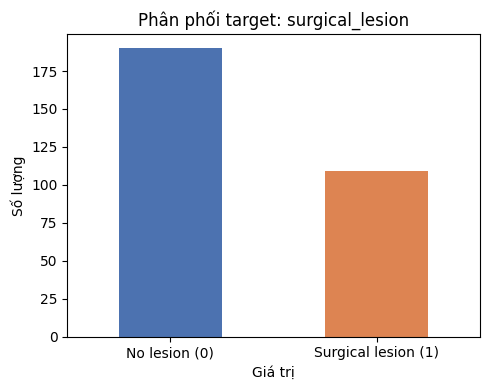

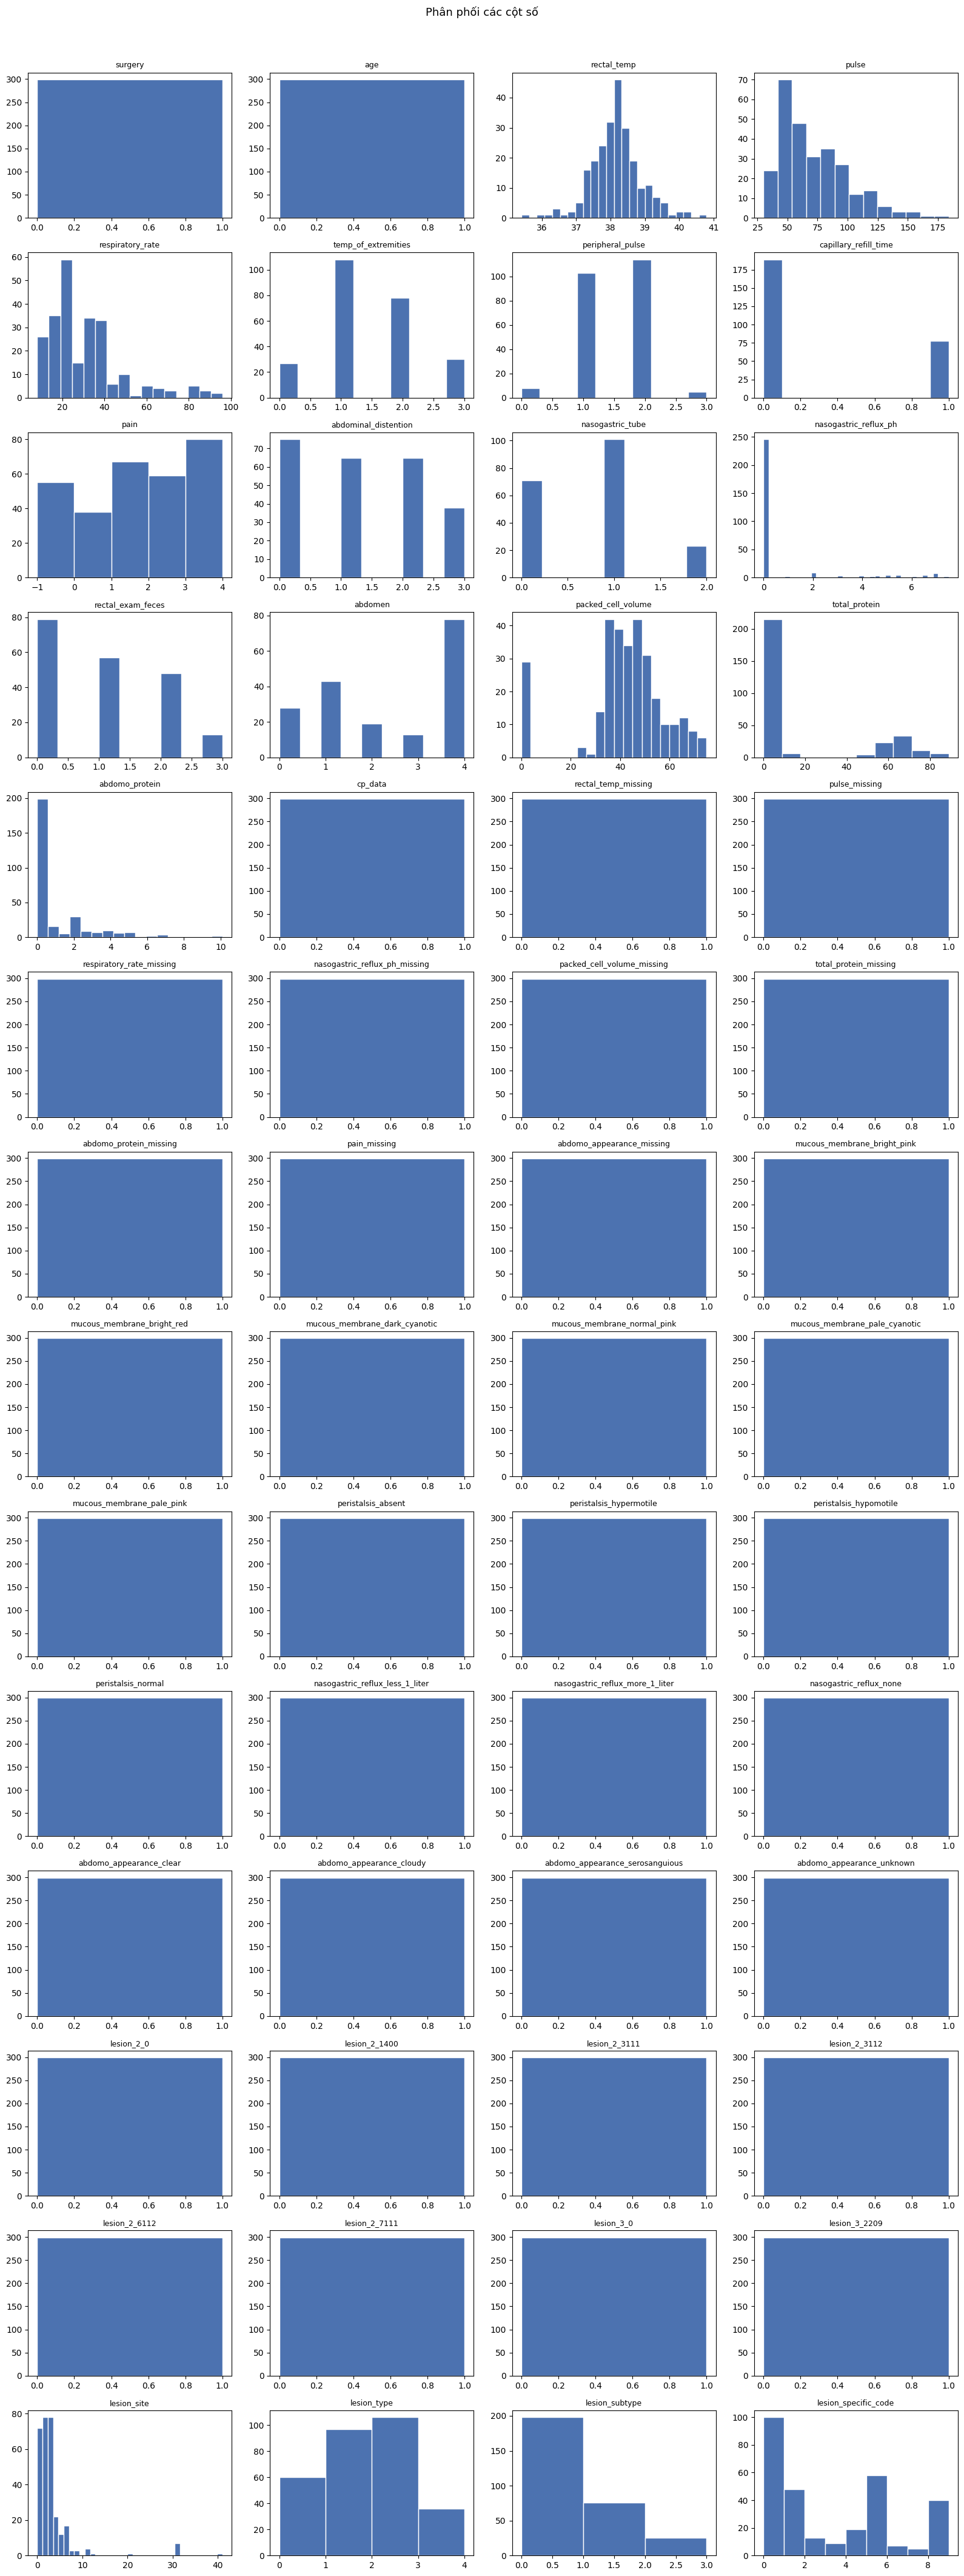

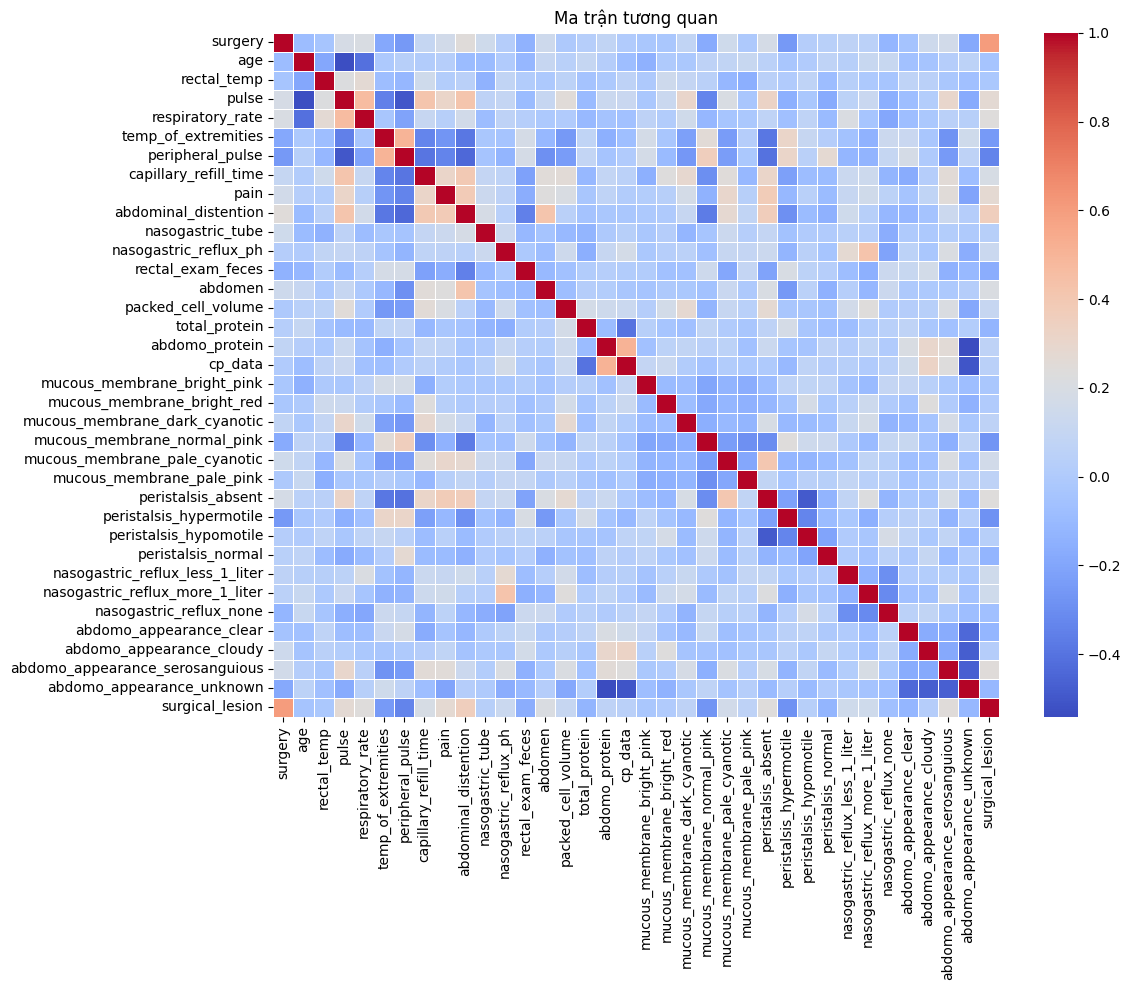

Bảng so sánh sơ bộ (F1 giảm dần)
                                    Method name  Avg_NRMSE        F1  Accuracy
3                                   KNN Imputer   0.292557  0.241949  0.561921
1  IterativeImputer\nBayesianRidge(max_iter=20)   0.275410  0.230492  0.585367
2                                Simple Imputer   0.301611  0.201087  0.558418
0                            Simple + Indicator   0.298553  0.196524  0.548531


In [9]:
from sklearn.pipeline import Pipeline
# Sử dụng bộ horse_colic đã được tiền xử lý
hc = pd.read_csv('../data/real data/horse_colic_clean.csv')
print(f"Kích thước: {hc.shape}")
print("Thống kê dữ liệu:\n")
display(hc.describe())

# Tiếp tục tiền xử lý thêm để phù hợp với bài làm
# Drop cột index vô nghĩa
hc = hc.drop(columns=['Unnamed: 0'])
 
# Encode cột string cp_data
hc['cp_data'] = (hc['cp_data'] == 'yes').astype(int)
 
# Encode tất cả cột boolean
bool_cols = hc.select_dtypes('bool').columns.tolist()
hc[bool_cols] = hc[bool_cols].astype(int)
physio_cols = ['rectal_temp', 'pulse', 'respiratory_rate']
for col in physio_cols:
    zeros = (hc[col] == 0).sum()
    print(f"  {col}: thay {zeros} giá trị 0 → NaN")
    hc[col] = hc[col].replace(0, np.nan)
 
print("\nMissing values sau tiền xử lý:")
missing = hc.isna().sum()
print(missing[missing > 0])
 
# ════════════════════════════════════════════
# PHÂN TÍCH KHÁM PHÁ (EDA)
# ════════════════════════════════════════════
 
# Phân phối target
target_col = 'surgical_lesion'
print(f"\nPhân phối target '{target_col}':")
print(hc[target_col].value_counts())
 
plt.figure(figsize=(5, 4))
hc[target_col].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Phân phối target: surgical_lesion')
plt.xlabel('Giá trị')
plt.ylabel('Số lượng')
plt.xticks([0, 1], ['No lesion (0)', 'Surgical lesion (1)'], rotation=0)
plt.tight_layout()
plt.show()
 
# Histogram các cột số
num_cols = hc.select_dtypes('number').drop(columns=[target_col]).columns.tolist()
n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(hc[col].dropna(), bins='auto', color='#4C72B0', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Phân phối các cột số', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()
 
# Ma trận tương quan (chỉ cột số, bỏ lesion_* và missing_* indicator)
core_cols = [c for c in num_cols if not c.startswith('lesion_') and not c.endswith('_missing')]
corr = hc[core_cols + [target_col]].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Ma trận tương quan')
plt.tight_layout()
plt.show()
 
# ════════════════════════════════════════════
# TÁCH FEATURES & TARGET, TRAIN-TEST SPLIT
# ════════════════════════════════════════════
X = hc.drop(columns=[target_col])
y = hc[target_col]

# IterativeImputer – 4 configurations
configs = {
    # IterativeImputer – 4 configurations
    'IterativeImputer\nBayesianRidge(max_iter=20)':  {'imputer': IterativeImputer(estimator=BayesianRidge(),
                                           max_iter=20, random_state=0), 'use_indicator': False},
    'SimpleImputer': {'imputer': SimpleImputer(strategy='mean'), 'use_indicator': False},
    'SimpleImputer + Indicator': {'imputer': SimpleImputer(strategy='mean'), 'use_indicator': True},
    'KNNImputer': {'imputer': KNNImputer(n_neighbors=5, weights='distance'), 'use_indicator': False}
}

# Display offsets of imputed features and orginal features for each configurations
hc_results = []

# Missing Indicator + Simple Imputer
simp_ind = SimpleImputer(strategy='mean')
simp_ind_res = missing_imputer(
    df=hc, 
    fold_method=cv, 
    clf_method=clf, 
    imputer_name='Simple + Indicator', 
    imputer_method=simp_ind, 
    add_indicator=True  # <--- Kích hoạt tính năng này
)
hc_results.append(simp_ind_res)

# Iterative Imputer
iter_bayesian = IterativeImputer(estimator=BayesianRidge(), max_iter=20, random_state=0)
IterI = missing_imputer(
    df=hc, 
    fold_method=cv, 
    clf_method=clf, 
    imputer_name='IterativeImputer\nBayesianRidge(max_iter=20)', 
    imputer_method=iter_bayesian, 
    add_indicator= False
)
hc_results.append(IterI)

# Simple Imputer
simp = SimpleImputer(strategy='mean')
simp_res = missing_imputer(
    df=hc, 
    fold_method=cv, 
    clf_method=clf, 
    imputer_name='Simple Imputer', 
    imputer_method=simp, 
    add_indicator=False
)
hc_results.append(simp_res)

# KNN Imputer
knn = KNNImputer(n_neighbors=5, weights='distance')
knn_res = missing_imputer(
    df=hc, 
    fold_method=cv, 
    clf_method=clf, 
    imputer_name='KNN Imputer', 
    imputer_method=knn, 
    add_indicator=False  # <--- Kích hoạt tính năng này
)
hc_results.append(knn_res)

hc_results = pd.DataFrame(hc_results)
print('Bảng so sánh sơ bộ (F1 giảm dần)')
print(hc_results.sort_values('F1', ascending=False))

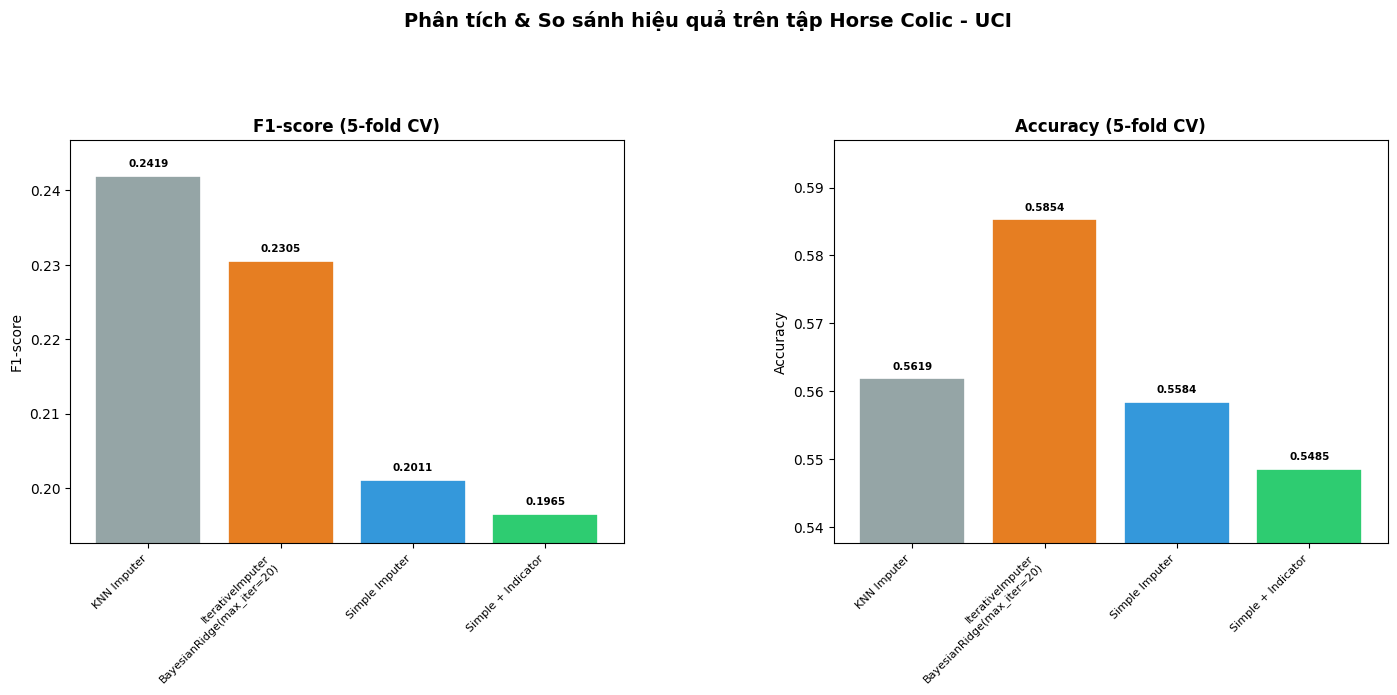

In [10]:
# Bar-charts
hc_results = pd.DataFrame(hc_results).sort_values('F1', ascending=False)
fig = plt.figure(figsize=(17, 13))
fig.suptitle("Phân tích & So sánh hiệu quả trên tập Horse Colic - UCI",
             fontsize=14, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.48, wspace=0.38)

# F1-score
ax1 = fig.add_subplot(gs[0, 0])
all_accs = hc_results['F1']
colors_all = ['#95a5a6','#e67e22','#3498db','#2ecc71','#1abc9c','#16a085','#27ae60']
bars1 = ax1.bar(range(len(hc_results['Method name'])), all_accs,
                color=colors_all, edgecolor='white', linewidth=1.2)

# Thiết lập trục X
ax1.set_xticks(range(len(hc_results['Method name'])))
ax1.set_xticklabels(hc_results['Method name'], fontsize=8, rotation=45, ha='right') # Xoay chữ 45 độ

# Thiết lập giới hạn trục Y cho dễ quan sát sự khác biệt
ax1.set_ylim(min(all_accs)*0.98, max(all_accs)*1.02)

ax1.set_title("F1-score (5-fold CV)", fontweight='bold')
ax1.set_ylabel("F1-score")
for bar, v in zip(bars1, all_accs):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.001,
             f'{v:.4f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    
# Accuracy
ax2 = fig.add_subplot(gs[0, 1])
all_accs = hc_results['Accuracy']
colors_all = ['#95a5a6','#e67e22','#3498db','#2ecc71','#1abc9c','#16a085','#27ae60']
bars2 = ax2.bar(range(len(hc_results['Method name'])), all_accs,
                color=colors_all, edgecolor='white', linewidth=1.2)

# Thiết lập trục X
ax2.set_xticks(range(len(hc_results['Method name'])))
ax2.set_xticklabels(hc_results['Method name'], fontsize=8, rotation=45, ha='right') # Xoay chữ 45 độ

# Thiết lập giới hạn trục Y cho dễ quan sát sự khác biệt
ax2.set_ylim(min(all_accs)*0.98, max(all_accs)*1.02)

ax2.set_title("Accuracy (5-fold CV)", fontweight='bold')
ax2.set_ylabel("Accuracy")
for bar, v in zip(bars2, all_accs):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.001,
             f'{v:.4f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

* World bank dataset

Kích thước: (5301, 11)
Thống kê dữ liệu:



,Year,Agri_GDP,Credit_Private,Elec_Access,Emp_Services,FDI_GDP,GDPC_2015,Indus_GDP,Internet_Usage,Serv_GDP
count,5301.000000,5301.000000,5301.000000,5301.000000,5301.000000,5301.000000,5301.000000,5301.000000,5301.000000,5301.000000
mean,2013.991322,10.359460,52.330812,82.201713,53.535482,3.630746,12209.463665,26.278247,43.901066,55.580758
std,6.045669,9.492725,38.650333,25.900926,16.841514,3.500881,14095.360260,10.575754,30.814564,12.091112
min,2004.000000,0.011489,0.000088,22.250000,6.643033,-4.359932,250.878933,2.086302,0.024337,23.562872
25%,2009.000000,2.496275,22.323775,68.900000,40.974711,1.403996,1806.383673,19.249783,14.813300,47.629688
50%,2014.000000,7.302135,43.248875,98.100000,53.598864,2.720599,5508.602656,25.221566,40.440000,54.658291
75%,2019.000000,16.457138,69.990215,100.000000,66.955758,5.246616,17938.094946,32.168275,71.962100,63.674233
max,2024.000000,37.398432,141.489874,100.000000,93.678238,11.010544,42135.661855,51.546014,100.000000,87.741049



Phân phối target 'Serv_GDP':
Serv_GDP
87.741049    62
23.562872    23
38.636645    14
56.550451    13
54.658163    13
             ..
34.974950     1
37.678032     1
28.660657     1
49.563454     1
50.605296     1
Name: count, Length: 4946, dtype: int64


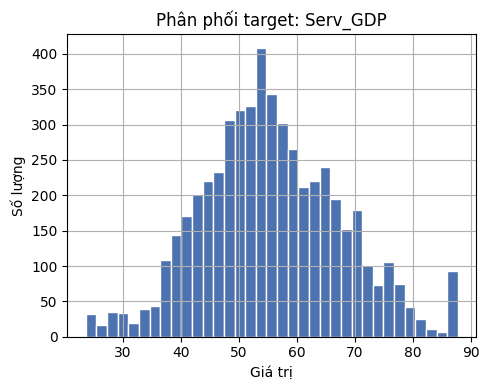

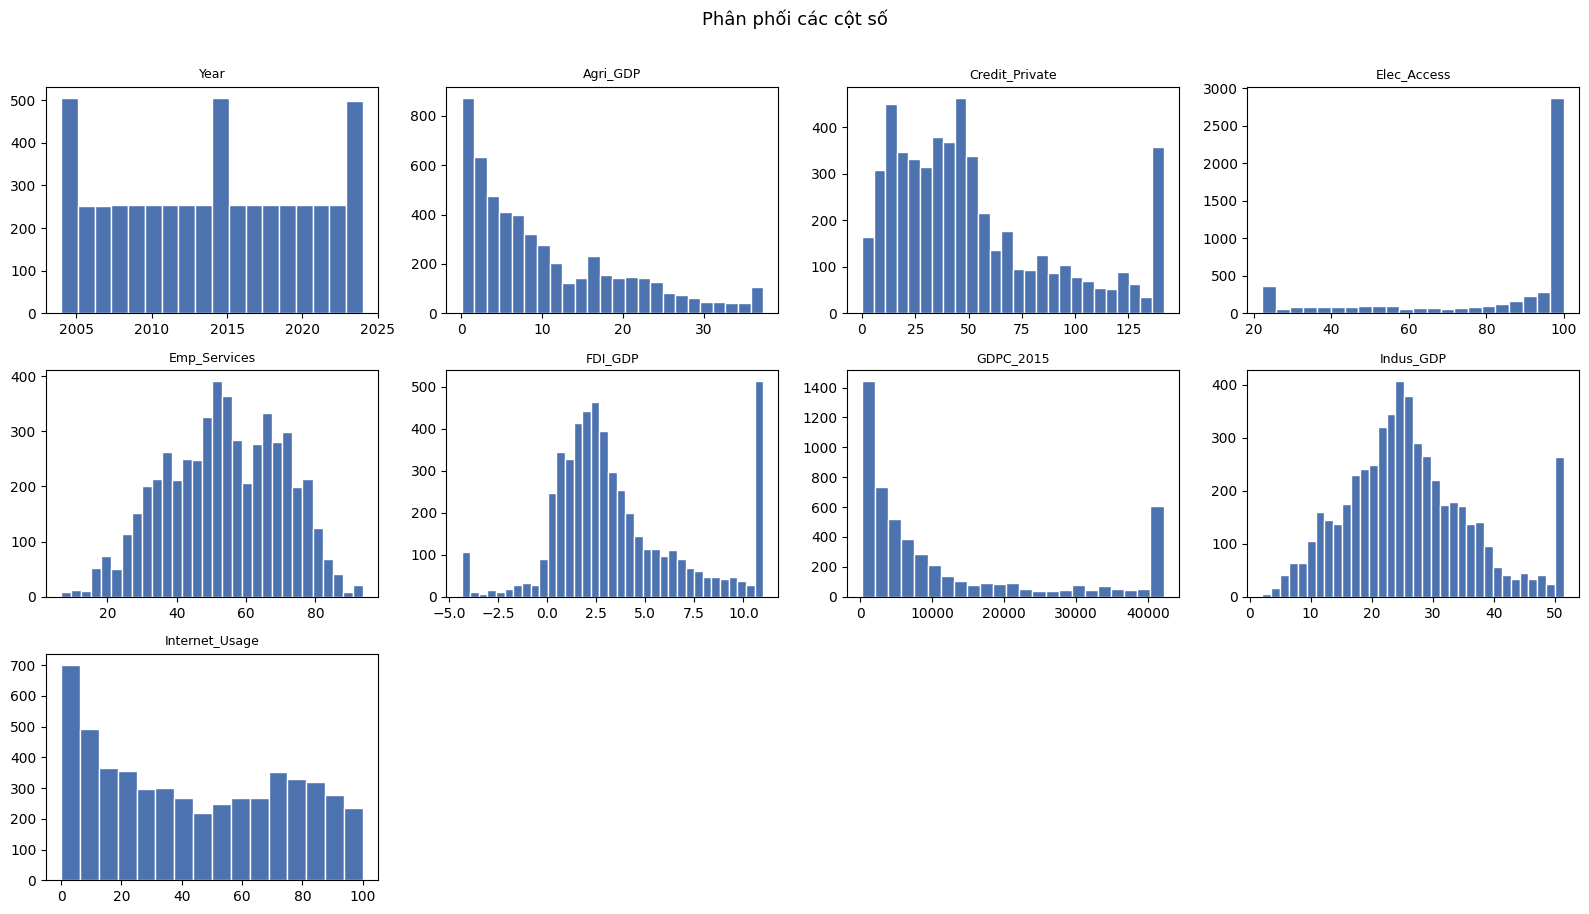

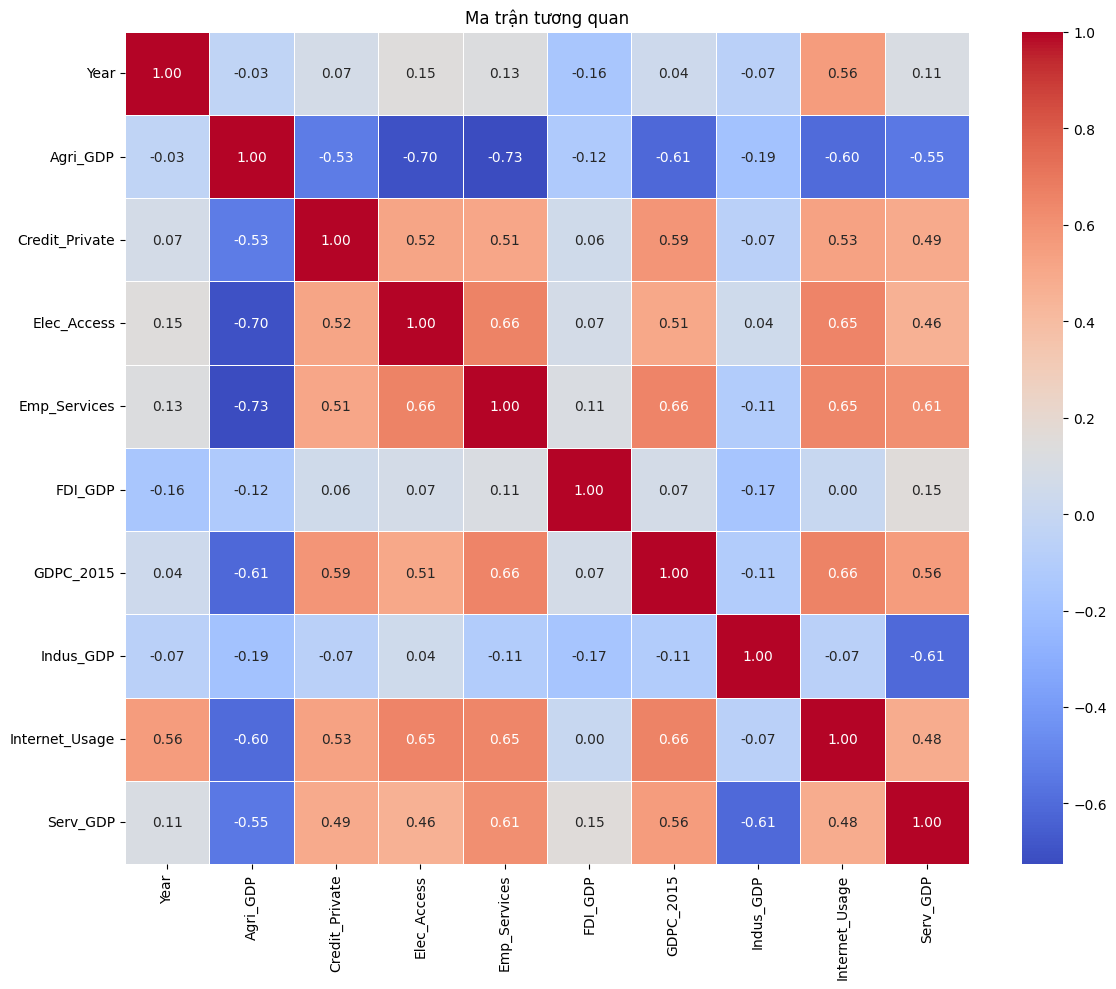

In [14]:
from sklearn.pipeline import Pipeline

wb = pd.read_csv('../data/real data/world_bank_clean.csv')
print(f"Kích thước: {wb.shape}")
print("Thống kê dữ liệu:\n")
display(wb.describe())

wb = wb.drop(columns=['Country'])

# Sử dụng bộ dữ liệu đã được điền khuyết logic để đánh giá hiệu quả imputation, 
# bằng cách thêm thêm dữ liệu thiếu ngẫu nhiên
 
# ════════════════════════════════════════════
# PHÂN TÍCH KHÁM PHÁ (EDA)
# ════════════════════════════════════════════
 
# Phân phối target
target_col = 'Serv_GDP'
print(f"\nPhân phối target '{target_col}':")
print(wb[target_col].value_counts())
 
plt.figure(figsize=(5, 4))
wb[target_col].hist(bins='auto', color='#4C72B0', edgecolor='white')
plt.title('Phân phối target: Serv_GDP')
plt.xlabel('Giá trị')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()
 
# Histogram các cột số
num_cols = wb.select_dtypes('number').drop(columns=[target_col]).columns.tolist()
n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(wb[col].dropna(), bins='auto', color='#4C72B0', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Phân phối các cột số', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()
 
# Ma trận tương quan (chỉ cột số, bỏ lesion_* và missing_* indicator)
core_cols = [c for c in num_cols if not c.startswith('lesion_') and not c.endswith('_missing')]
corr = wb[core_cols + [target_col]].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, fmt='.2f', annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Ma trận tương quan')
plt.tight_layout()
plt.show()
 
# ════════════════════════════════════════════
# TÁCH FEATURES & TARGET, TRAIN-TEST SPLIT
# ════════════════════════════════════════════
# Dùng KFold cho biến mục tiêu dạng continuous
cv = KFold(n_splits=5) # train/ test: 80/20
reg = RandomForestRegressor(n_estimators=100, random_state=42)

# IterativeImputer – 4 configurations
configs = {
    # IterativeImputer – 4 configurations
    'IterativeImputer\nBayesianRidge(max_iter=20)':  {'imputer': IterativeImputer(estimator=BayesianRidge(),
                                           max_iter=20, random_state=0), 'use_indicator': False},
    'SimpleImputer': {'imputer': SimpleImputer(strategy='mean'), 'use_indicator': False},
    'SimpleImputer + Indicator': {'imputer': SimpleImputer(strategy='mean'), 'use_indicator': True},
    'KNNImputer': {'imputer': KNNImputer(n_neighbors=5, weights='distance'), 'use_indicator': False}
}

# Display offsets of imputed features and orginal features for each configurations
wb_results = []
# Missing Indicator + Simple Imputer
simp_ind = SimpleImputer(strategy='mean')
simp_ind_res = missing_imputer(
    df=hc, 
    fold_method=cv, 
    clf_method=clf, 
    imputer_name='Simple + Indicator', 
    imputer_method=simp_ind, 
    add_indicator=True  # <--- Kích hoạt tính năng này
)
wb_results.append(simp_ind_res)

# Iterative Imputer
iter_bayesian = IterativeImputer(estimator=BayesianRidge(), max_iter=20, random_state=0)
IterI = missing_imputer(
    df=hc, 
    fold_method=cv, 
    clf_method=clf, 
    imputer_name='IterativeImputer\nBayesianRidge(max_iter=20)', 
    imputer_method=iter_bayesian, 
    add_indicator= False
)
wb_results.append(IterI)

# Simple Imputer
simp = SimpleImputer(strategy='mean')
simp_res = missing_imputer(
    df=hc, 
    fold_method=cv, 
    clf_method=clf, 
    imputer_name='Simple Imputer', 
    imputer_method=simp, 
    add_indicator=False
)
wb_results.append(simp_res)

# KNN Imputer
knn = KNNImputer(n_neighbors=5, weights='distance')
knn_res = missing_imputer(
    df=hc, 
    fold_method=cv, 
    clf_method=clf, 
    imputer_name='KNN Imputer', 
    imputer_method=knn, 
    add_indicator=False
)
wb_results.append(knn_res)

Bảng so sánh sơ bộ (F1 giảm dần)
                                    Method name  Avg_NRMSE        F1  Accuracy
3                                   KNN Imputer   0.293590  0.290289  0.595085
1  IterativeImputer\nBayesianRidge(max_iter=20)   0.263187  0.241080  0.568249
0                            Simple + Indicator   0.298397  0.220624  0.571469
2                                Simple Imputer   0.301510  0.200889  0.541638


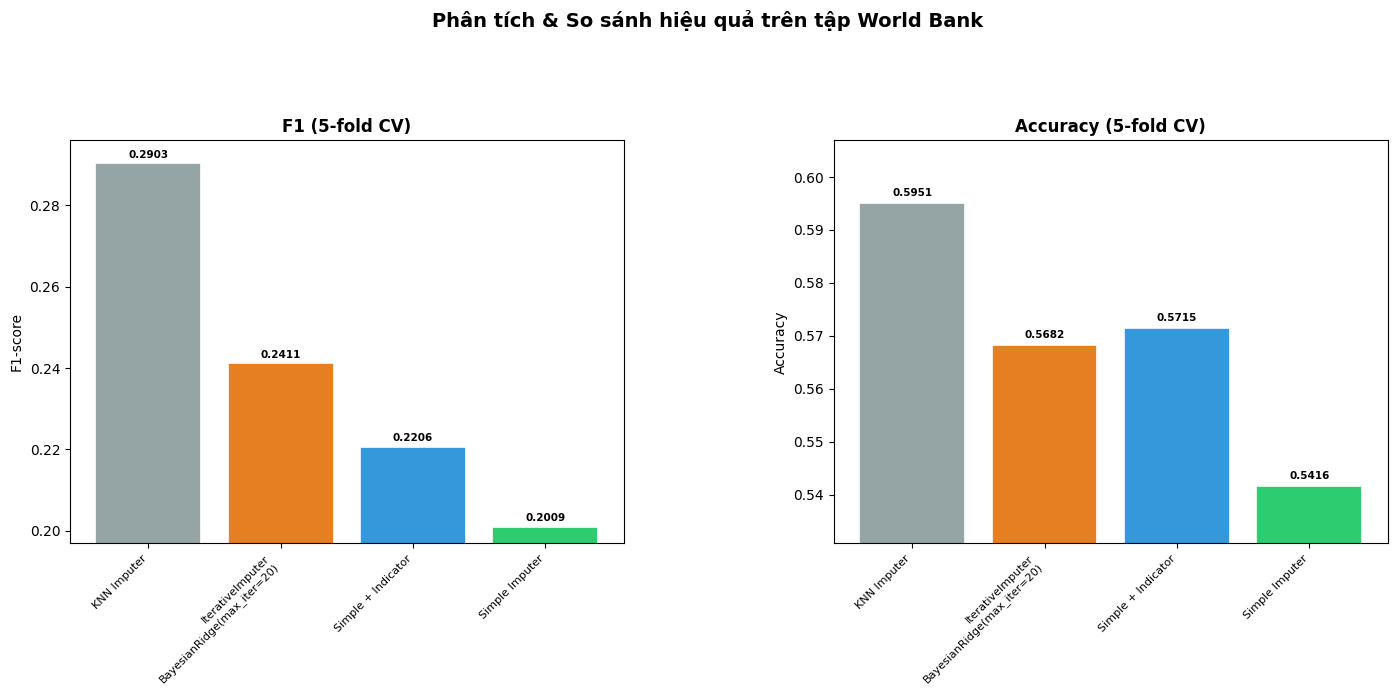

In [15]:
# Bar-charts
wb_results = pd.DataFrame(wb_results)
print('Bảng so sánh sơ bộ (F1 giảm dần)')
print(wb_results.sort_values('F1', ascending=False))
wb_results = pd.DataFrame(wb_results).sort_values('F1', ascending=False)
fig = plt.figure(figsize=(17, 13))
fig.suptitle("Phân tích & So sánh hiệu quả trên tập World Bank",
             fontsize=14, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.48, wspace=0.38)

# MAE
ax1 = fig.add_subplot(gs[0, 0])
all_accs = wb_results['F1']
colors_all = ['#95a5a6','#e67e22','#3498db','#2ecc71','#1abc9c','#16a085','#27ae60']
bars1 = ax1.bar(range(len(wb_results['Method name'])), all_accs,
                color=colors_all, edgecolor='white', linewidth=1.2)

# Thiết lập trục X
ax1.set_xticks(range(len(wb_results['Method name'])))
ax1.set_xticklabels(wb_results['Method name'], fontsize=8, rotation=45, ha='right') # Xoay chữ 45 độ

# Thiết lập giới hạn trục Y cho dễ quan sát sự khác biệt
ax1.set_ylim(min(all_accs)*0.98, max(all_accs)*1.02)

ax1.set_title("F1 (5-fold CV)", fontweight='bold')
ax1.set_ylabel("F1-score")
for bar, v in zip(bars1, all_accs):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.001,
             f'{v:.4f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    
# MSE
ax2 = fig.add_subplot(gs[0, 1])
all_accs = wb_results['Accuracy']
colors_all = ['#95a5a6','#e67e22','#3498db','#2ecc71','#1abc9c','#16a085','#27ae60']
bars2 = ax2.bar(range(len(wb_results['Method name'])), all_accs,
                color=colors_all, edgecolor='white', linewidth=1.2)

# Thiết lập trục X
ax2.set_xticks(range(len(wb_results['Method name'])))
ax2.set_xticklabels(wb_results['Method name'], fontsize=8, rotation=45, ha='right') # Xoay chữ 45 độ

# Thiết lập giới hạn trục Y cho dễ quan sát sự khác biệt
ax2.set_ylim(min(all_accs)*0.98, max(all_accs)*1.02)

ax2.set_title("Accuracy (5-fold CV)", fontweight='bold')
ax2.set_ylabel("Accuracy")
for bar, v in zip(bars2, all_accs):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.001,
             f'{v:.4f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')